In [3]:
import numpy as np; 
import matplotlib.pyplot as plt;

Optimal N1 for N = 1000 is 108
Optimal N1 for N = 10000 is 284


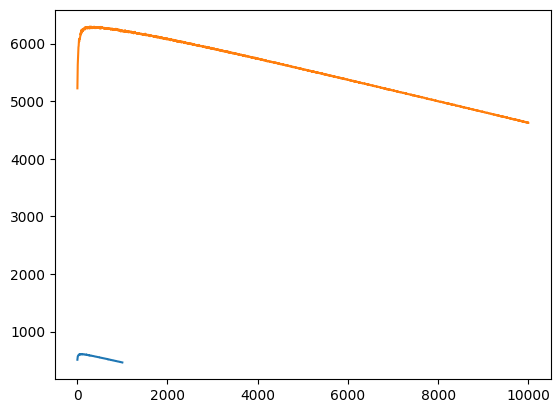

In [4]:
#AlgorithmA - System 1 - K = 4, p1 = 0.2, p2 0.4, p3=0.6, p4 = 0.65, a1=a2=a3=a4=2
N_arr = [1000, 10000]

def plotN(N): 
    def revenue(N1): 
        revenues = [0,0,0,0]
        probabilities = [0.2, 0.4, 0.6, 0.65]
        for i in range(0,4):
            click = np.random.choice([1,0], p=[probabilities[i], 1-probabilities[i]], size=N1//4)
            pay = np.random.uniform(0,2, size =N1//4)
            revenue = click * pay
            revenues[i] = np.sum(revenue)
        max_index = np.argmax(revenues)
        click = np.random.choice([1,0], p=[probabilities[max_index], 1-probabilities[max_index]], size=N-N1)
        pay = np.random.uniform(0,2, size = N-N1)
        revenues[max_index] += np.sum(click * pay)
        return (np.sum(revenues))
    myArr = []
    for N1 in range(4,N+1,4):
        sampleSum = 0
        for j in range(0,1000): 
            sampleSum += revenue(N1)
        sampleAverage = sampleSum/1000
        myArr.append(sampleAverage)
    plt.plot(range(4,N+1,4), myArr) 
    max_index = np.argmax(myArr) 
    optimal_N1 = (max_index+1)*4
    print("Optimal N1 for N =", N, "is", optimal_N1)
    return optimal_N1
    
optimal_vals = [plotN(1000), plotN(10000)]

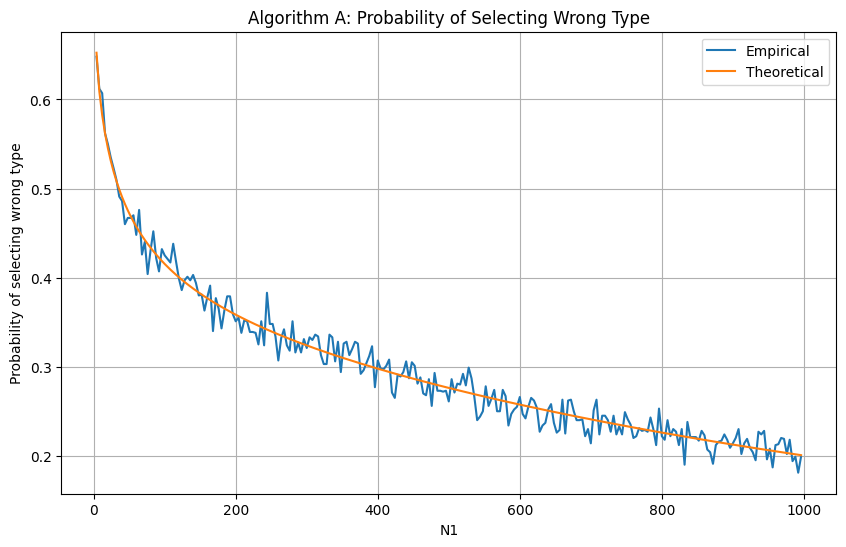

In [5]:
#Expected revenue from video of type k = (ak/2)*pk. 
#So after N1 samples, the video of that type must be picked which has maximum pk since all ak are given equal 
#Thus, 4th type is the best type. But we have to compute the theoretical probability of not selecting 4th type
# P(not 4th type) = 1 - P(4th type) = 1- P(R4 > R1,R2,R3) = 1 - P(R4 > R1)*P(R4 > R2)*P(R4 > R3)
# Also the probability distribution of each is such : f(0)dx = 1-pk, f(x) = pk/(ak) for 0<x<ak
# thus, F(x) = 0 for x<0, F(x) = 1-pk + pk*x/ak for 0<x<ak, F(x) = 1 for x>ak
# P(x>R3) = F(x) 
# Thus, P(R4>R3,R2,R1) = integral from 0 to a4 of f4(x)*F3(x)*F2(x)*F1(x) dx = F3(x)*F2(x)*F1(x)dF4(x)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, irwinhall
from scipy.integrate import quad

p = [0.2, 0.4, 0.6, 0.65]
a = 2

# CDF of total revenue of m users of type k
def total_cdf(x, m, pk):
    if x < 0:
        return 0
    if x >= 2*m:
        return 1

    j = np.arange(1, m + 1)
    probs = binom.pmf(j, m, pk)

    # Conditional on j clicks, revenue is sum of j U(0,2)'s
    cdf = np.sum(probs * irwinhall.cdf(x/2, j))

    # j=0 => total revenue = 0 <= x
    cdf += binom.pmf(0, m, pk)

    return cdf


# PDF of total revenue of m users of type k
def total_pdf(x, m, pk):
    if x <= 0 or x >= 2*m:
        return 0

    j = np.arange(1, m + 1)
    probs = binom.pmf(j, m, pk)

    return np.sum(probs * irwinhall.pdf(x/2, j) / 2)


# Theoretical probability that type 4 is selected
def theoretical_correct(N1):
    m = N1 // 4

    def integrand(x):
        return (
            total_cdf(x, m, p[0]) *
            total_cdf(x, m, p[1]) *
            total_cdf(x, m, p[2]) *
            total_pdf(x, m, p[3])
        )

    return quad(integrand, 0, 2*m, limit=100)[0]


# Empirical probability
def empirical_wrong(N1, trials=1000):
    wrong = 0
    m = N1 // 4

    for _ in range(trials):
        revenues = []

        for pk in p:
            clicks = np.random.choice(
                [1, 0], size=m, p=[pk, 1-pk]
            )
            pay = np.random.uniform(0, 2, size=m)
            revenues.append(np.sum(clicks * pay))

        if np.argmax(revenues) != 3:
            wrong += 1

    return wrong / trials


# Do the experiment
N = 1000

N1_values = np.arange(4, N, 4)

empirical = []
theoretical = []

for N1 in N1_values:
    empirical.append(empirical_wrong(N1))
    theoretical.append(1 - theoretical_correct(N1))

# Plot
plt.figure(figsize=(10,6))
plt.plot(N1_values, empirical, label="Empirical")
plt.plot(N1_values, theoretical, label="Theoretical")
plt.xlabel("N1")
plt.ylabel("Probability of selecting wrong type")
plt.title("Algorithm A: Probability of Selecting Wrong Type")
plt.legend()
plt.grid()
plt.show()